In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix)
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              HistGradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [26]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()

Train shape: (594194, 21)
Test shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [ ]:
original = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
original = original.rename(columns={'customerID': 'id'})
original['TotalCharges'] = pd.to_numeric(original['TotalCharges'], errors='coerce')
original['TotalCharges'] = original['TotalCharges'].fillna(original['MonthlyCharges'])
print(f"Original dataset loaded: {original.shape}")
use_original = True

In [ ]:
common_cols = [c for c in train.columns if c in original.columns and c != 'id']
print(f"Common columns: {len(common_cols)}")

combined = pd.concat([train[common_cols], original[common_cols]], axis=0, ignore_index=True)
print(f"Combined train shape: {combined.shape} (was {train.shape[0]})")

In [30]:
# Work on a copy for EDA
eda_df = combined.copy()
eda_df['Churn'] = eda_df['Churn'].map({'Yes': 1, 'No': 0})

# Handle TotalCharges conversion issues
eda_df['TotalCharges'] = pd.to_numeric(eda_df['TotalCharges'], errors='coerce')
eda_df['TotalCharges'] = eda_df['TotalCharges'].fillna(eda_df['MonthlyCharges'])

X_eda = eda_df.drop('Churn', axis=1)
y_eda = eda_df['Churn']

categorical_cols_eda = X_eda.select_dtypes(include=['object']).columns.tolist()
numerical_cols_eda = X_eda.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {categorical_cols_eda}")
print(f"Numerical columns: {numerical_cols_eda}")
print(f"Churn rate: {y_eda.mean():.2%}")

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Churn rate: 22.57%


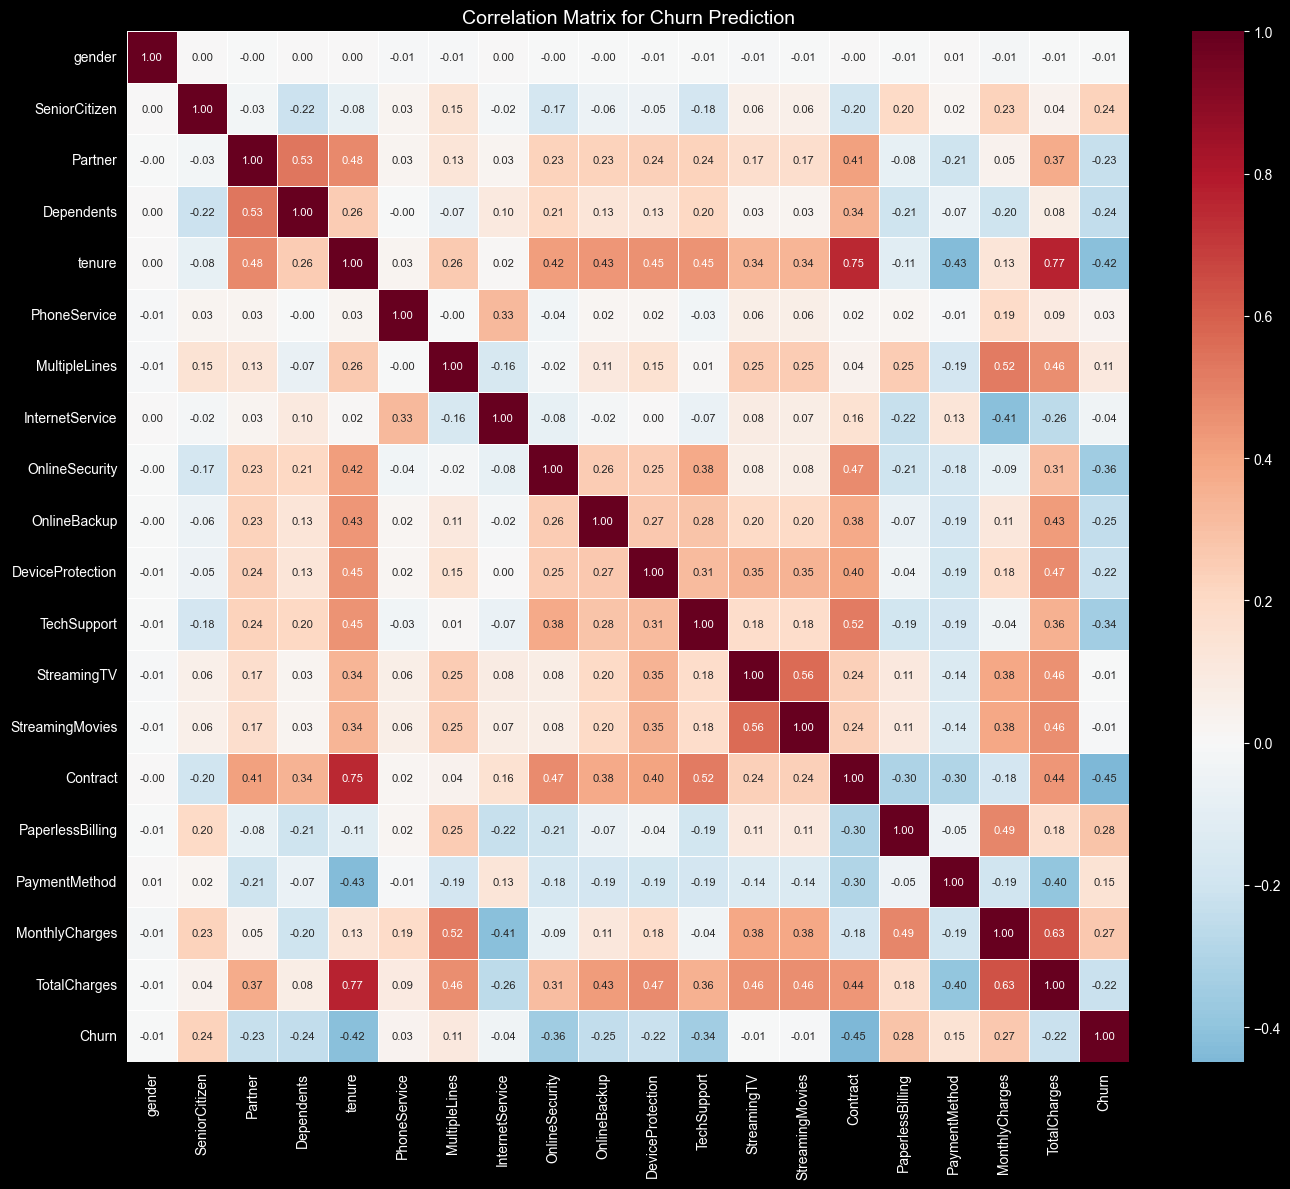


Correlations with Churn (sorted by absolute value):
Contract           -0.448717
tenure             -0.417732
OnlineSecurity     -0.355914
TechSupport        -0.341767
PaperlessBilling    0.283866
MonthlyCharges      0.271974
OnlineBackup       -0.245983
Dependents         -0.239419
SeniorCitizen       0.235248
Partner            -0.227310
TotalCharges       -0.218195
DeviceProtection   -0.217965
PaymentMethod       0.150526
MultipleLines       0.108759
InternetService    -0.041727
PhoneService        0.034316
StreamingMovies    -0.008495
gender             -0.006814
StreamingTV        -0.005579
Name: Churn, dtype: float64


In [31]:
X_eda_encoded = X_eda.copy()
for col in categorical_cols_eda:
    le = LabelEncoder()
    X_eda_encoded[col] = le.fit_transform(X_eda_encoded[col].astype(str))

X_with_target = X_eda_encoded.copy()
X_with_target['Churn'] = y_eda

correlation_matrix = X_with_target.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlation Matrix for Churn Prediction', fontsize=14)
plt.tight_layout()
plt.show()

print("\nCorrelations with Churn (sorted by absolute value):")
churn_corr = correlation_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr)

In [32]:
def engineer_features(df):
    """Apply all feature engineering to a dataframe."""
    df = df.copy()

    # Handle TotalCharges
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

    # --- Tenure-based features ---
    df['tenure_group'] = pd.cut(df['tenure'], bins=[-1, 6, 12, 24, 48, 72, 200],
                                labels=['0-6m', '6-12m', '1-2yr', '2-4yr', '4-6yr', '6+yr'])

    df['is_new_customer'] = (df['tenure'] <= 6).astype(int)
    df['is_long_tenure'] = (df['tenure'] >= 48).astype(int)

    # --- Charges-based features ---
    df['avg_monthly_charges'] = df['TotalCharges'] / (df['tenure'] + 1)
    df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)
    df['charge_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
    df['charges_deviation'] = df['MonthlyCharges'] - df['avg_monthly_charges']
    df['high_monthly_charges'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

    # --- Service-based features ---
    service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['total_services'] = (df[service_cols] == 'Yes').sum(axis=1)

    # Has internet dependent services
    internet_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                         'TechSupport', 'StreamingTV', 'StreamingMovies']
    df['internet_service_count'] = (df[internet_services] == 'Yes').sum(axis=1)

    # Protection-related
    df['has_any_protection'] = ((df['OnlineSecurity'] == 'Yes') |
                                (df['TechSupport'] == 'Yes') |
                                (df['DeviceProtection'] == 'Yes') |
                                (df['OnlineBackup'] == 'Yes')).astype(int)

    df['has_streaming'] = ((df['StreamingTV'] == 'Yes') |
                           (df['StreamingMovies'] == 'Yes')).astype(int)

    # --- Contract & billing interactions ---
    df['is_long_term'] = (df['Contract'] != 'Month-to-month').astype(int)

    # Key interaction: month-to-month + high charges = high churn risk
    df['mtm_high_charges'] = ((df['Contract'] == 'Month-to-month') &
                               (df['MonthlyCharges'] > df['MonthlyCharges'].median())).astype(int)

    # Electronic check + month-to-month = very high risk
    df['risky_payment'] = ((df['PaymentMethod'] == 'Electronic check') &
                            (df['Contract'] == 'Month-to-month')).astype(int)

    # New customer + no protection
    df['vulnerable_new'] = ((df['tenure'] <= 12) &
                             (df['has_any_protection'] == 0)).astype(int)

    # Tenure * contract interaction
    df['tenure_x_contract'] = df['tenure'] * df['is_long_term']

    # Monthly charges per service
    df['charges_per_service'] = df['MonthlyCharges'] / (df['total_services'] + 1)

    return df

print("Feature engineering function defined.")

Feature engineering function defined.


In [33]:
# Apply to combined training data
train_fe = engineer_features(combined)
train_fe['Churn'] = train_fe['Churn'].map({'Yes': 1, 'No': 0})

# Apply to test data
test_fe = engineer_features(test.drop('id', axis=1))
test_ids = test['id'].copy()

X = train_fe.drop('Churn', axis=1)
y = train_fe['Churn']

print(f"Training features shape: {X.shape}")
print(f"Test features shape: {test_fe.shape}")
print(f"Churn rate: {y.mean():.2%}")

Training features shape: (601237, 37)
Test features shape: (254655, 37)
Churn rate: 22.57%


In [34]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Fit on combined train + test to handle unseen labels
    all_vals = pd.concat([X[col].astype(str), test_fe[col].astype(str)], axis=0)
    le.fit(all_vals)
    X[col] = le.transform(X[col].astype(str))
    test_fe[col] = le.transform(test_fe[col].astype(str))
    label_encoders[col] = le

print(f"\nFinal feature count: {X.shape[1]}")
print("Encoding complete (no scaling — tree models don't need it).")

Categorical columns (16): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Numerical columns (21): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'is_new_customer', 'is_long_tenure', 'avg_monthly_charges', 'charges_per_tenure', 'charge_ratio', 'charges_deviation', 'high_monthly_charges', 'total_services', 'internet_service_count', 'has_any_protection', 'has_streaming', 'is_long_term', 'mtm_high_charges', 'risky_payment', 'vulnerable_new', 'tenure_x_contract', 'charges_per_service']

Final feature count: 37
Encoding complete (no scaling — tree models don't need it).


In [ ]:
# --- Subsample for fast Optuna hyperparameter search ---
# Using 20% stratified sample cuts tuning time by ~5x with minimal accuracy loss.
# Final models are always trained on the full dataset.
OPTUNA_SAMPLE_FRAC = 0.20
_, X_opt, _, y_opt = train_test_split(
    X, y,
    test_size=OPTUNA_SAMPLE_FRAC,
    stratify=y,
    random_state=42,
)
print(f"Optuna search set: {X_opt.shape[0]} rows ({OPTUNA_SAMPLE_FRAC:.0%} of full data)")

In [35]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Churn rate in training: {y_train.mean():.2%}")
print(f"Churn rate in validation: {y_val.mean():.2%}")

Training set size: 480989
Validation set size: 120248
Churn rate in training: 22.57%
Churn rate in validation: 22.57%


In [36]:
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_val_scaled = scaler_lr.transform(X_val)

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), False),
    'Random Forest': (RandomForestClassifier(n_estimators=100, random_state=42), False),
    'Gradient Boosting': (GradientBoostingClassifier(n_estimators=100, random_state=42), False),
}

results = []
trained_models = {}

for name, (model, needs_scaling) in models.items():
    print(f"Training {name}...")
    Xtr = X_train_scaled if needs_scaling else X_train
    Xvl = X_val_scaled if needs_scaling else X_val
    model.fit(Xtr, y_train)
    trained_models[name] = model

    y_pred = model.predict(Xvl)
    y_prob = model.predict_proba(Xvl)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1 Score': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_prob)
    })

results_df = pd.DataFrame(results)
print("\nBaseline Model Comparison:")
print(results_df.to_string(index=False))

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

Baseline Model Comparison:
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression  0.856388   0.700732 0.634705  0.666087 0.910818
      Decision Tree  0.803706   0.563784 0.575377  0.569521 0.722872
      Random Forest  0.848929   0.690897 0.598224  0.641229 0.900731
  Gradient Boosting  0.858201   0.707616 0.633379  0.668443 0.912489


In [37]:
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
best_model = trained_models[best_model_name]

print(f"Best baseline model: {best_model_name}")
print(f"ROC-AUC: {results_df['ROC-AUC'].max():.4f}")

needs_scaling = models[best_model_name][1]
Xvl = X_val_scaled if needs_scaling else X_val
y_pred_best = best_model.predict(Xvl)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_best, target_names=['No Churn', 'Churn']))
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred_best))

Best baseline model: Gradient Boosting
ROC-AUC: 0.9125

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91     93111
       Churn       0.71      0.63      0.67     27137

    accuracy                           0.86    120248
   macro avg       0.80      0.78      0.79    120248
weighted avg       0.85      0.86      0.86    120248

Confusion Matrix:
[[86009  7102]
 [ 9949 17188]]


In [ ]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 1e-8, 5.0, log=True),
        'tree_method': 'hist',   # histogram method — much faster than exact
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'auc',
        'verbosity': 0,
        'n_jobs': -1,
    }
    model = xgb.XGBClassifier(**params)
    # 3-fold CV on 20% subsample — ~10x faster, params generalise to full data
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_opt, y_opt, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("Tuning XGBoost with Optuna (50 trials, 3-fold on 20% subsample)...")
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)
print(f"Best XGBoost ROC-AUC: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

In [ ]:
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'n_jobs': -1,
        'random_state': 42,
        'verbose': -1,
    }
    model = lgb.LGBMClassifier(**params)
    # 3-fold CV on 20% subsample — ~10x faster, params generalise to full data
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_opt, y_opt, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("Tuning LightGBM with Optuna (50 trials, 3-fold on 20% subsample)...")
study_lgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=50, show_progress_bar=True)
print(f"Best LightGBM ROC-AUC: {study_lgb.best_value:.4f}")
print(f"Best params: {study_lgb.best_params}")

In [ ]:
def objective_hgb(trial):
    params = {
        'max_iter': trial.suggest_int('max_iter', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 20, 150),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 100),
        'l2_regularization': trial.suggest_float('l2_regularization', 1e-8, 10.0, log=True),
        'random_state': 42,
    }
    model = HistGradientBoostingClassifier(**params)
    # 3-fold CV on 20% subsample — same strategy as XGBoost/LightGBM tuning
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_opt, y_opt, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

print("Tuning HistGradientBoostingClassifier with Optuna (50 trials, 3-fold on 20% subsample)...")
study_hgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study_hgb.optimize(objective_hgb, n_trials=50, show_progress_bar=True)
print(f"Best HistGBM ROC-AUC: {study_hgb.best_value:.4f}")
print(f"Best params: {study_hgb.best_params}")

In [ ]:
# XGBoost with best params
best_xgb = xgb.XGBClassifier(
    **study_xgb.best_params,
    tree_method='hist',
    random_state=42,
    use_label_encoder=False,
    eval_metric='auc',
    verbosity=0,
    n_jobs=-1,
)

# LightGBM with best params
best_lgb = lgb.LGBMClassifier(
    **study_lgb.best_params,
    n_jobs=-1,
    random_state=42,
    verbose=-1,
)

# HistGradientBoostingClassifier with Optuna-tuned params (random_state already in best_params)
best_gb = HistGradientBoostingClassifier(**study_hgb.best_params)

tuned_models = {
    'XGBoost (tuned)': best_xgb,
    'LightGBM (tuned)': best_lgb,
    'HistGradientBoosting': best_gb,
}

# Evaluate each on validation set
results_v2 = []
trained_models_v2 = {}

for name, model in tuned_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models_v2[name] = model

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    results_v2.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1 Score': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_prob)
    })

results_v2_df = pd.DataFrame(results_v2)
print("\nTuned Model Comparison:")
print(results_v2_df.to_string(index=False))

In [ ]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print("3-Fold Cross-Validation (full data):")
cv_results = {}
for name, model in tuned_models.items():
    cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = cv_scores
    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

best_model_name_v2 = max(cv_results, key=lambda k: cv_results[k].mean())
print(f"\nBest single model: {best_model_name_v2}")

In [ ]:
# Retrain all models on FULL training data for final predictions
print("Retraining all models on full training data for ensemble...")
final_models = {}
for name, model_template in tuned_models.items():
    model = type(model_template)(**model_template.get_params())
    model.fit(X, y)
    final_models[name] = model
    print(f"  {name} trained on {X.shape[0]} samples.")

# Reuse trained_models_v2 (already trained on X_train) — no redundant retraining
val_probs = {name: model.predict_proba(X_val)[:, 1]
             for name, model in trained_models_v2.items()}

# Search for best ensemble weights
best_ensemble_score = 0
best_weights = None
model_names = list(val_probs.keys())

for w1 in np.arange(0.1, 0.9, 0.05):
    for w2 in np.arange(0.1, 0.9 - w1, 0.05):
        w3 = 1.0 - w1 - w2
        if w3 < 0.05:
            continue
        blend = (w1 * val_probs[model_names[0]] +
                 w2 * val_probs[model_names[1]] +
                 w3 * val_probs[model_names[2]])
        score = roc_auc_score(y_val, blend)
        if score > best_ensemble_score:
            best_ensemble_score = score
            best_weights = (w1, w2, w3)

print(f"\nBest ensemble weights:")
for name, w in zip(model_names, best_weights):
    print(f"  {name}: {w:.2f}")
print(f"Ensemble ROC-AUC on validation: {best_ensemble_score:.4f}")

In [43]:
# Get probability predictions from each final model
test_probs = {}
for name, model in final_models.items():
    test_probs[name] = model.predict_proba(test_fe)[:, 1]
    print(f"{name} — mean prob: {test_probs[name].mean():.4f}")

# Ensemble blend
test_ensemble_prob = np.zeros(len(test_fe))
for name, w in zip(model_names, best_weights):
    test_ensemble_prob += w * test_probs[name]

print(f"\nEnsemble — mean prob: {test_ensemble_prob.mean():.4f}")
print(f"Ensemble — min: {test_ensemble_prob.min():.4f}, max: {test_ensemble_prob.max():.4f}")

# ==> CRITICAL: Submit PROBABILITIES, not 0/1 labels! <==
submission = pd.DataFrame({
    'id': test_ids,
    'Churn': test_ensemble_prob
})

print("\nSubmission preview:")
print(submission.head(10))
print(f"\nTotal predictions: {len(submission)}")

XGBoost (tuned) — mean prob: 0.2186
LightGBM (tuned) — mean prob: 0.2186
Gradient Boosting — mean prob: 0.2187

Ensemble — mean prob: 0.2186
Ensemble — min: 0.0006, max: 0.9814

Submission preview:
       id     Churn
0  594194  0.077094
1  594195  0.001185
2  594196  0.106917
3  594197  0.003567
4  594198  0.469055
5  594199  0.176365
6  594200  0.907505
7  594201  0.001976
8  594202  0.026828
9  594203  0.314725

Total predictions: 254655


In [44]:
submission.to_csv('submission.csv', index=False)
print("Final submission saved to 'submission.csv'")

# Verify format matches sample
saved = pd.read_csv('submission.csv')
print("\nSaved submission verification:")
print(saved.head(10))
print(f"\nColumn dtypes:\n{saved.dtypes}")
print(f"\nChurn stats:\n{saved['Churn'].describe()}")

# Sanity check: values should be probabilities between 0 and 1
assert saved['Churn'].between(0, 1).all(), "ERROR: Churn values are not probabilities!"
print("\nSanity check passed: all values are between 0 and 1.")

Final submission saved to 'submission.csv'

Saved submission verification:
       id     Churn
0  594194  0.077094
1  594195  0.001185
2  594196  0.106917
3  594197  0.003567
4  594198  0.469055
5  594199  0.176365
6  594200  0.907505
7  594201  0.001976
8  594202  0.026828
9  594203  0.314725

Column dtypes:
id         int64
Churn    float64
dtype: object

Churn stats:
count    254655.000000
mean          0.218605
std           0.275377
min           0.000592
25%           0.006541
50%           0.063398
75%           0.392602
max           0.981381
Name: Churn, dtype: float64

Sanity check passed: all values are between 0 and 1.
